# Sample CMIP6 Data

This notebook demonstrates how to access CMIP6 data on JASMIN via the CEDA Archive. As an example, it uses UKESM1‑0‑LL SSP585 and SSP534-over projections to create a sample dataset. The workflow reads monthly model output, computes annual‑mean fields, and saves the processed data to NetCDF files for downstream analysis.

- All CMIP6 data is stored at `/badc/cmip6/data/CMIP6/`.
- UKESM1-0-LL SSP585 output is at `/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/`.
- UKESM1-0-LL SSP534-over output is at `/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/`.
- UKESM1-0-LL historical output is at `/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/`.

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [14]:
dir_path = "/badc/cmip6/data/CMIP6/" # this is the directory for all cmip6 output

# ------ read ukesm-0-ll data (near-surface temperature, 'tas' diagnostic) ------------
# here, we use r1i1p1f2 ensemble member for testing. Ideally, we would use the mean of all ensemble members.

ds_ssp585 = xr.open_mfdataset(dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Amon/tas/gn/latest/*nc")
ds_ssp534over = xr.open_mfdataset(dir_path + "ScenarioMIP/MOHC/UKESM1-0-LL/ssp534-over/r1i1p1f2/Amon/tas/gn/latest/*nc") 

In [15]:
print(ds_ssp585)
print(ds_ssp534over)

<xarray.Dataset> Size: 120MB
Dimensions:    (time: 1032, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 8kB 2015-01-16 00:00:00 ... 2100-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B 1.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 17kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 2MB dask.array<chunksize=(420, 144, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 3MB dask.array<chunksize=(420, 192, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 114MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent: 

In [16]:
# Compute annual-means

days = ds_ssp585['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_ssp585 = (ds_ssp585 * weights).groupby('time.year').sum(dim='time') 

days = ds_ssp534over['time'].dt.days_in_month
weights = days.groupby('time.year') / days.groupby('time.year').sum(dim='time')
ds_ssp534over = (ds_ssp534over * weights).groupby('time.year').sum(dim='time') 

print(ds_ssp585)

<xarray.Dataset> Size: 19MB
Dimensions:   (year: 86, lat: 144, bnds: 2, lon: 192)
Coordinates:
  * lat       (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * year      (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (year, lat, bnds) float64 198kB dask.array<chunksize=(35, 144, 2), meta=np.ndarray>
    lon_bnds  (year, lon, bnds) float64 264kB dask.array<chunksize=(35, 192, 2), meta=np.ndarray>
    tas       (year, lat, lon) float64 19MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>


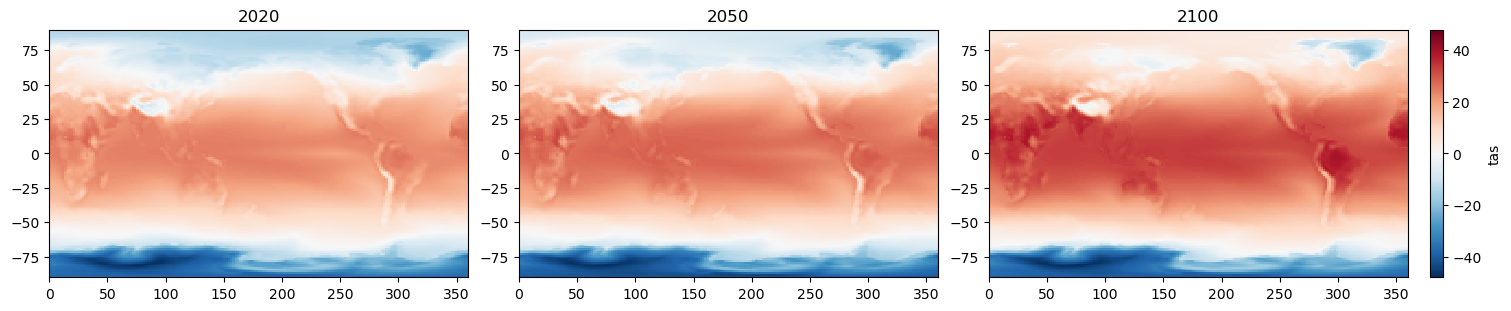

In [20]:
# plot (SSP585)
years = [2020, 2050, 2100]

fig, axes = plt.subplots(ncols=3, figsize=(15, 3), constrained_layout=True)

for ax, year in zip(axes, years):
    tas_year = ds_ssp585["tas"].sel(year=year, method="nearest") - 273.15
    
    tas_year.plot(ax=ax, cmap="RdBu_r", add_colorbar=(year == years[-1])  # show colorbar only once
        )
    
    ax.set_title(str(year))
    ax.set_xlabel("")
    ax.set_ylabel("")


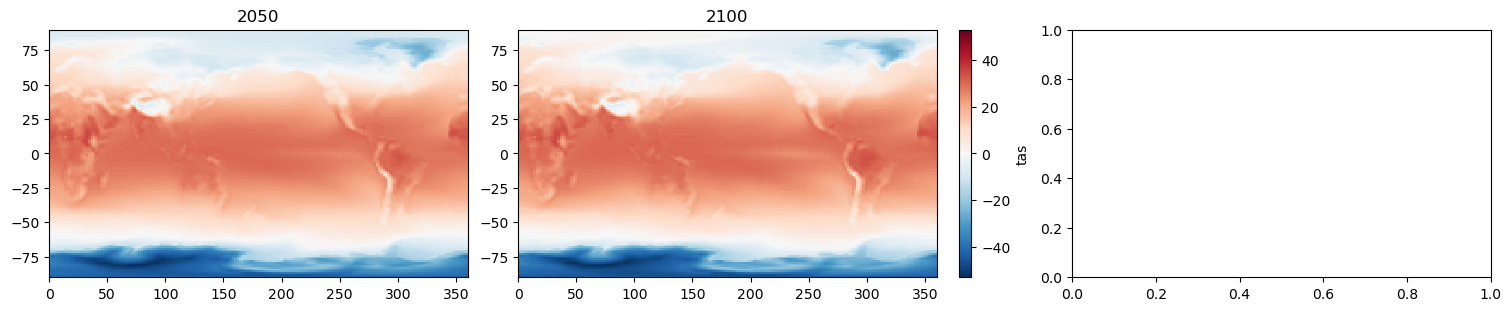

In [23]:
# plot (SSP534-over)
years = [2050, 2100]

fig, axes = plt.subplots(ncols=3, figsize=(15, 3), constrained_layout=True)

for ax, year in zip(axes, years):
    tas_year = ds_ssp534over["tas"].sel(year=year, method="nearest") - 273.15
    
    tas_year.plot(ax=ax, cmap="RdBu_r", add_colorbar=(year == years[-1])  # show colorbar only once
        )
    
    ax.set_title(str(year))
    ax.set_xlabel("")
    ax.set_ylabel("")

In [26]:
# Save Data

ds_ssp585.astype(np.float32).to_netcdf("./sample-ssp585.nc")
ds_ssp534over.astype(np.float32).to_netcdf("./sample-ssp534-over.nc")